In [ ]:
import boto3
import pandas as pd
import json
import os
from io import BytesIO
from datetime import datetime
from dotenv import load_dotenv

load_dotenv(dotenv_path=r"C:\Users\ASUS\weather-delay-risk\.env")

s3 = boto3.client(
    "s3",
    region_name=os.getenv("AWS_REGION"),
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY")
)

BUCKET   = os.getenv("AWS_BUCKET_NAME")
TODAY    = "2026-07-08"  
AIRPORTS = ["JFK", "LAX", "ORD", "ATL", "DFW"]

print("✅ Ready")

c:\Users\ASUS\weather-delay-risk\venv\lib\site-packages\boto3\compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


✅ Ready


In [2]:
def read_parquet_from_s3(key):
    response = s3.get_object(Bucket=BUCKET, Key=key)
    buffer = BytesIO(response["Body"].read())
    return pd.read_parquet(buffer)

# Load cleaned weather and flights
df_weather = read_parquet_from_s3(f"processed/weather/{TODAY}/all_airports.parquet")
df_flights = read_parquet_from_s3(f"processed/flights/{TODAY}/all_airports.parquet")

print("Weather shape:", df_weather.shape)
print("Flights shape:", df_flights.shape)

df_weather.head()

Weather shape: (240, 7)
Flights shape: (331554, 9)


,timestamp,temperature,precipitation,windspeed,visibility,airport,date
0,2026-07-07 00:00:00,19.1,0.0,19.1,13800.0,JFK,2026-07-07
1,2026-07-07 01:00:00,18.8,0.4,13.8,13300.0,JFK,2026-07-07
2,2026-07-07 02:00:00,18.9,0.0,11.9,14100.0,JFK,2026-07-07
3,2026-07-07 03:00:00,18.8,0.0,13.0,12900.0,JFK,2026-07-07
4,2026-07-07 04:00:00,18.7,0.0,13.2,12400.0,JFK,2026-07-07


In [3]:
# Aggregate weather by airport and date
weather_agg = df_weather.groupby(["airport", "date"]).agg(
    avg_windspeed    = ("windspeed",    "mean"),
    max_windspeed    = ("windspeed",    "max"),
    total_precip     = ("precipitation","sum"),
    avg_visibility   = ("visibility",   "mean"),
    min_visibility   = ("visibility",   "min"),
).reset_index()

# Normalize each factor to a 0-1 scale
# Higher wind = higher risk
weather_agg["wind_risk"] = (weather_agg["max_windspeed"] / 100).clip(0, 1)

# Higher precipitation = higher risk
weather_agg["precip_risk"] = (weather_agg["total_precip"] / 20).clip(0, 1)

# Lower visibility = higher risk (visibility in meters, 10000m = perfect)
weather_agg["visibility_risk"] = (1 - weather_agg["min_visibility"] / 10000).clip(0, 1)

print("Weather features:")
weather_agg.head()

Weather features:


,airport,date,avg_windspeed,max_windspeed,total_precip,avg_visibility,min_visibility,wind_risk,precip_risk,visibility_risk
0,ATL,2026-07-07,8.295833,14.5,9.7,22929.166667,13500.0,0.145,0.485,0.0
1,ATL,2026-07-08,10.404167,18.9,0.0,28258.333333,14800.0,0.189,0.000,0.0
2,DFW,2026-07-07,7.808333,17.1,0.0,39587.500000,21300.0,0.171,0.000,0.0
3,DFW,2026-07-08,12.312500,16.9,0.0,36570.833333,20200.0,0.169,0.000,0.0
4,JFK,2026-07-07,13.641667,19.1,0.4,14391.666667,12400.0,0.191,0.020,0.0


In [11]:
# Aggregate historical delay rate per airport
flight_agg = df_flights.groupby("ORIGIN").agg(
    total_flights         = ("FL_DATE",        "count"),
    delay_rate            = ("is_delayed",         "mean"),
    weather_delay_rate    = ("is_weather_delayed", "mean"),
    cancellation_rate     = ("is_cancelled",       "mean"),
    avg_dep_delay         = ("DEP_DELAY",           "mean"),
).reset_index()

flight_agg.rename(columns={"ORIGIN": "airport"}, inplace=True)

# Historical delay is also a risk factor
flight_agg["historical_risk"] = (flight_agg["weather_delay_rate"]).clip(0, 1)

print("Flight features:")
flight_agg

Flight features:


,airport,total_flights,delay_rate,weather_delay_rate,cancellation_rate,avg_dep_delay,historical_risk
0,ATL,80811,0.203660,0.009553,0.018760,11.324226,0.009553
1,DFW,79113,0.268489,0.026279,0.024130,17.943739,0.026279
2,JFK,25181,0.175529,0.003296,0.011437,10.320956,0.003296
3,LAX,48137,0.185845,0.003303,0.007583,10.043958,0.003303
4,ORD,98312,0.253296,0.027525,0.033628,19.345848,0.027525


In [10]:
print("Weather columns:", df_weather.columns.tolist())
print("Flights columns:", df_flights.columns.tolist())

Weather columns: ['timestamp', 'temperature', 'precipitation', 'windspeed', 'visibility', 'airport', 'date']
Flights columns: ['FL_DATE', 'ORIGIN', 'DEP_DELAY', 'ARR_DELAY', 'CANCELLED', 'WEATHER_DELAY', 'is_delayed', 'is_weather_delayed', 'is_cancelled']


In [12]:
# Merge weather and flight features
df_risk = weather_agg.merge(flight_agg[["airport", "historical_risk", "delay_rate", "avg_dep_delay"]], 
                             on="airport", how="left")

# --- Final Risk Score (weighted average) ---
# Weights reflect how much each factor contributes to delays
WEIGHT_WIND        = 0.25
WEIGHT_PRECIP      = 0.30
WEIGHT_VISIBILITY  = 0.25
WEIGHT_HISTORICAL  = 0.20

df_risk["risk_score"] = (
    WEIGHT_WIND       * df_risk["wind_risk"]       +
    WEIGHT_PRECIP     * df_risk["precip_risk"]     +
    WEIGHT_VISIBILITY * df_risk["visibility_risk"] +
    WEIGHT_HISTORICAL * df_risk["historical_risk"]
).round(3)

# Risk label
def label(score):
    if score < 0.2:  return "🟢 Low"
    if score < 0.4:  return "🟡 Moderate"
    if score < 0.6:  return "🟠 High"
    return "🔴 Severe"

df_risk["risk_label"] = df_risk["risk_score"].apply(label)

# Final output columns
output = df_risk[["airport", "date", "risk_score", "risk_label",
                   "avg_windspeed", "total_precip", "avg_visibility",
                   "delay_rate", "avg_dep_delay"]].copy()

print("✅ Risk scores computed!")
output.sort_values("risk_score", ascending=False)

✅ Risk scores computed!


,airport,date,risk_score,risk_label,avg_windspeed,total_precip,avg_visibility,delay_rate,avg_dep_delay
0,ATL,2026-07-07,0.184,🟢 Low,8.295833,9.7,22929.166667,0.203660,11.324226
4,JFK,2026-07-07,0.054,🟢 Low,13.641667,0.4,14391.666667,0.175529,10.320956
6,LAX,2026-07-07,0.053,🟢 Low,8.570833,0.0,16775.000000,0.185845,10.043958
1,ATL,2026-07-08,0.049,🟢 Low,10.404167,0.0,28258.333333,0.203660,11.324226
3,DFW,2026-07-08,0.048,🟢 Low,12.312500,0.0,36570.833333,0.268489,17.943739
2,DFW,2026-07-07,0.048,🟢 Low,7.808333,0.0,39587.500000,0.268489,17.943739
7,LAX,2026-07-08,0.045,🟢 Low,9.187500,0.0,18216.666667,0.185845,10.043958
8,ORD,2026-07-07,0.043,🟢 Low,5.854167,0.0,32270.833333,0.253296,19.345848
9,ORD,2026-07-08,0.041,🟢 Low,7.591667,0.0,36533.333333,0.253296,19.345848
5,JFK,2026-07-08,0.035,🟢 Low,9.366667,0.0,18466.666667,0.175529,10.320956


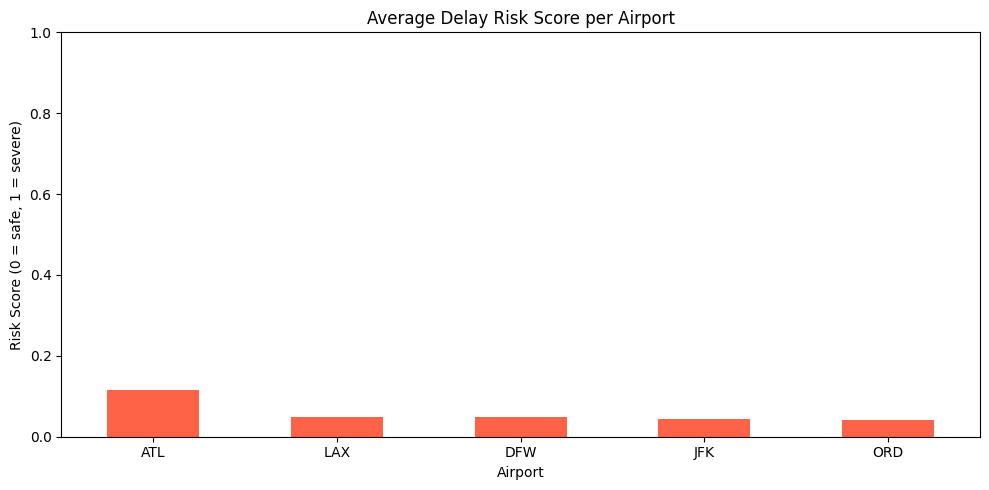

In [13]:
import matplotlib.pyplot as plt

pivot = output.pivot_table(index="airport", values="risk_score", aggfunc="mean").sort_values("risk_score", ascending=False)

pivot.plot(kind="bar", figsize=(10, 5), color="tomato", legend=False)
plt.title("Average Delay Risk Score per Airport")
plt.ylabel("Risk Score (0 = safe, 1 = severe)")
plt.xlabel("Airport")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [14]:
def upload_parquet(df, s3_key):
    buffer = BytesIO()
    df.to_parquet(buffer, index=False)
    buffer.seek(0)
    s3.put_object(Bucket=BUCKET, Key=s3_key, Body=buffer.getvalue())
    print(f"✅ Uploaded: {s3_key}")

upload_parquet(output, f"serving/risk_scores/{TODAY}/risk_scores.parquet")
print("🎉 Risk scores saved to S3 serving layer!")

✅ Uploaded: serving/risk_scores/2026-07-08/risk_scores.parquet
🎉 Risk scores saved to S3 serving layer!
